In [29]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch


In [39]:
from relevant_dicts import JP_MODIFIER_EXPLANATIONS,EN_MODIFIER_EXPLANATIONS
JP_MODIFIERS = list(JP_MODIFIER_EXPLANATIONS.keys())
EN_MODIFIERS = list(EN_MODIFIER_EXPLANATIONS.keys())
jp_tokenizer = AutoTokenizer.from_pretrained("cl-tohoku/bert-base-japanese")
en_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:

def enumerate_wordpiece_segmentations(word, tokenizer, max_pieces=4):
    """
    DP over all ways to split `word` into vocab-valid WordPiece pieces.
    Returns a list of token-id lists (each a valid full segmentation of `word`).
    """
    n = len(word)
    # dp[i] = list of valid token-id sequences that cover word[:i]
    dp = [[] for _ in range(n + 1)]
    dp[0] = [[]]

    for i in range(n):
        if not dp[i]:
            continue
        for j in range(i + 1, n + 1):
            if j - i > 20:  # safety cap on piece length
                break
            piece = word[i:j]
            candidate = piece if i == 0 else "##" + piece
            tok_id = tokenizer.vocab.get(candidate) if hasattr(tokenizer, "vocab") else None
            if tok_id is None:
                tok_id = tokenizer.convert_tokens_to_ids(candidate)
                if tok_id == tokenizer.unk_token_id:
                    continue
            for prefix_seq in dp[i]:
                if len(prefix_seq) < max_pieces:
                    dp[j].append(prefix_seq + [tok_id])

    return dp[n]
import itertools

def enumerate_wordpiece_segmentations_multiword(phrase, tokenizer, max_pieces=4):
    """
    Handles multi-word phrases (e.g. 'a little') by splitting on whitespace
    first — WordPiece never lets a ## continuation piece cross a space — then
    enumerating segmentations per word and taking the cartesian product across
    words, concatenating ids in order.
    """
    words = phrase.split()
    if len(words) == 1:
        return enumerate_wordpiece_segmentations(phrase, tokenizer, max_pieces=max_pieces)

    per_word_segs = [enumerate_wordpiece_segmentations(w, tokenizer, max_pieces=max_pieces) for w in words]
    if any(not segs for segs in per_word_segs):
        return []  # one of the words itself has no valid segmentation

    combined = []
    for combo in itertools.product(*per_word_segs):
        merged = [tok_id for seg in combo for tok_id in seg]
        if len(merged) <= max_pieces * len(words):  # loosen cap proportionally for phrases
            combined.append(merged)
    return combined
def enumerate_variant_segmentations(candidate_str, tokenizer, max_pieces=4, sep="・"):
    """
    candidate_str may contain multiple orthographic variants of the same word,
    e.g. 'すこし・少し'. Splits on `sep`, enumerates valid WordPiece segmentations
    for each variant, and pools them into one deduplicated list — since they're
    just different spellings of the same underlying modifier, their probabilities
    all get marginalized together later.
    """
    variants = [v for v in candidate_str.split(sep) if v]  # drop empty strings from stray separators
    seen = set()
    segmentations = []

    for variant in variants:
        for seg in enumerate_wordpiece_segmentations_multiword(variant, tokenizer, max_pieces=max_pieces):
            key = tuple(seg)
            if key not in seen:
                seen.add(key)
                segmentations.append(seg)

    return segmentations

JP_MODIFIER_SEGMENTATIONS = {
    cand: enumerate_variant_segmentations(cand, jp_tokenizer, max_pieces=4)
    for cand in JP_MODIFIERS
}
EN_MODIFIER_SEGMENTATIONS = {
    cand: enumerate_variant_segmentations(cand, en_tokenizer, max_pieces=4)
    for cand in EN_MODIFIERS 
}
tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForMaskedLM.from_pretrained(model_name)
    model.eval()
    model.to(device)
    cls_id = tokenizer.cls_token_id
    sep_id = tokenizer.sep_token_id
    mask_id = tokenizer.mask_token_id

Create token dictionary

In [ ]:
def score_word_in_sentence(sentence_template, target_word,model_name="bert-base-uncased"):
    idx = sentence_template.find(PLACEHOLDER)
    if idx == -1:
        raise ValueError(f"{PLACEHOLDER!r} not found in template")

    prefix = sentence_template[:idx]
    suffix = sentence_template[idx + len(PLACEHOLDER):]


    prefix_ids = tokenizer.encode(prefix, add_special_tokens=False)
    suffix_ids = tokenizer.encode(suffix, add_special_tokens=False)
    prefix_len = len(prefix_ids)

    target_ids_list = JP_MODIFIER_SEGMENTATIONS.get(target_word) or EN_MODIFIER_SEGMENTATIONS.get(target_word)
    if not target_ids_list:
        raise ValueError(f"No segmentation found for {target_word!r}")

    variant_log_sums = []
    variant_lengths = []

    for word_ids_full in target_ids_list:
        k = len(word_ids_full)
        log_prob_sum = 0.0
        with torch.inference_mode():
            for i in range(k):
                word_ids = word_ids_full[:i] + [mask_id] * (k - i)
                full_ids = [cls_id] + prefix_ids + word_ids + suffix_ids + [sep_id]
                input_ids = torch.tensor([full_ids], device=device)

                target_pos = 1 + prefix_len + i
                logits = model(input_ids).logits[0]
                token_log_probs = torch.log_softmax(logits[target_pos], dim=-1)  # renamed, no more shadowing
                log_prob_sum += token_log_probs[word_ids_full[i]].item()

        variant_log_sums.append(log_prob_sum)   # plain float, no .item() needed
        variant_lengths.append(k)

    # marginalize across segmentation variants (sum in probability space)
    marginal_log_sum = torch.logsumexp(torch.tensor(variant_log_sums), dim=0).item()

    return marginal_log_sum
def get_candidate_scores(sentence_template, candidates):
    """metric: 'mean' (length-normalized) or 'sum' (raw joint log-prob)"""
    scores = {}
    for word in candidates:
        scores[word] = score_word_in_sentence(sentence_template, word)
    return scores

In [33]:
PLACEHOLDER = "__MOD__"
jp_sentence_templates = ["幸助は「あの部屋、__MOD__寒いのですが…」と言い、会議を別の部屋でしたいと上司にお願いします。","幸助は初めて入った会議室で、隣に座っている同僚に「この部屋、__MOD__寒いですね」と言い、温度を上げてもらうように頼みます。","幸助は同じチームの暑がりの同僚に、「またかよ…」と思いながら「部屋が__MOD__寒いんだけど」ともんくをいいます。"]

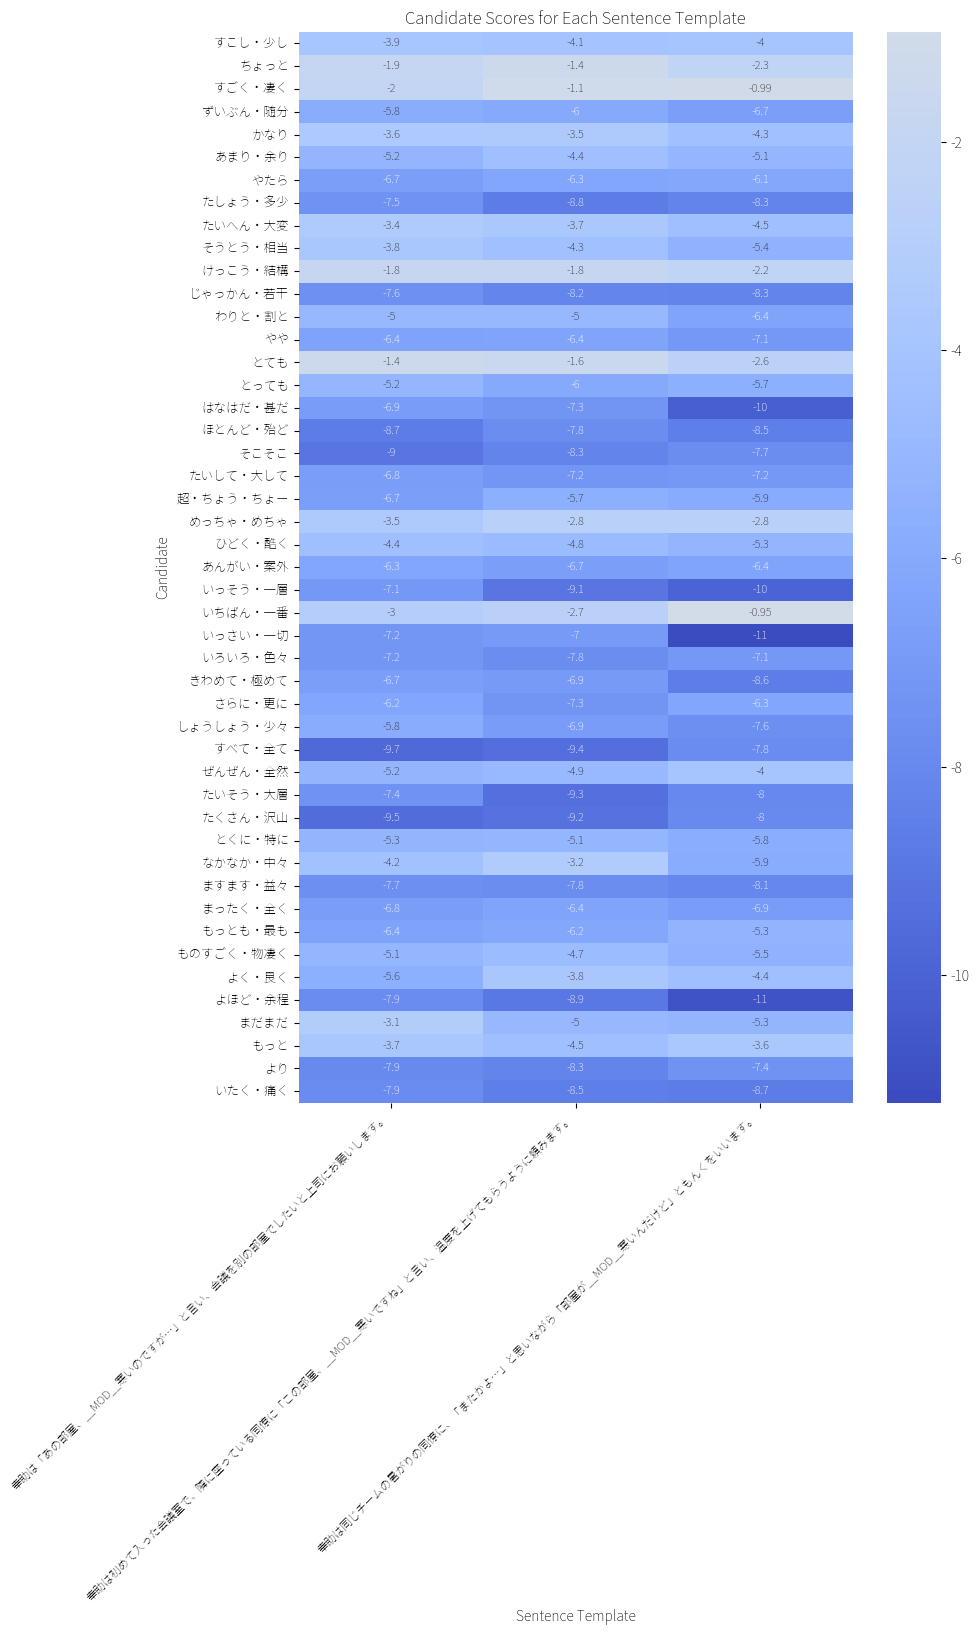

In [34]:
# df = pd.read_csv("/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/Aug11perturb_context_results.csv", index_col=0)  # columns = sentence templates, index = candidates
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
# filter rows where value is below -8 for all columns
df = df[(df > -8).any(axis=1)]
plt.rcParams['font.family'] = 'Noto Sans CJK JP'
# plt.rcParams['font.family'] = 'Hiragana Sans' # whatever you confirmed is installed
plt.rcParams['axes.unicode_minus'] = False

n_rows, n_cols = len(df.index), len(df.columns)
fig, ax = plt.subplots(figsize=(max(10, n_cols * 3), max(6, n_rows * 0.35)))

sns.heatmap(df, annot=True, cmap="coolwarm", center=0, ax=ax,
            annot_kws={"fontsize": 8})
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9, rotation=0)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8, rotation=45, ha="right")

ax.set_title("Candidate Scores for Each Sentence Template")
ax.set_xlabel("Sentence Template")
ax.set_ylabel("Candidate")

plt.tight_layout()
plt.show()

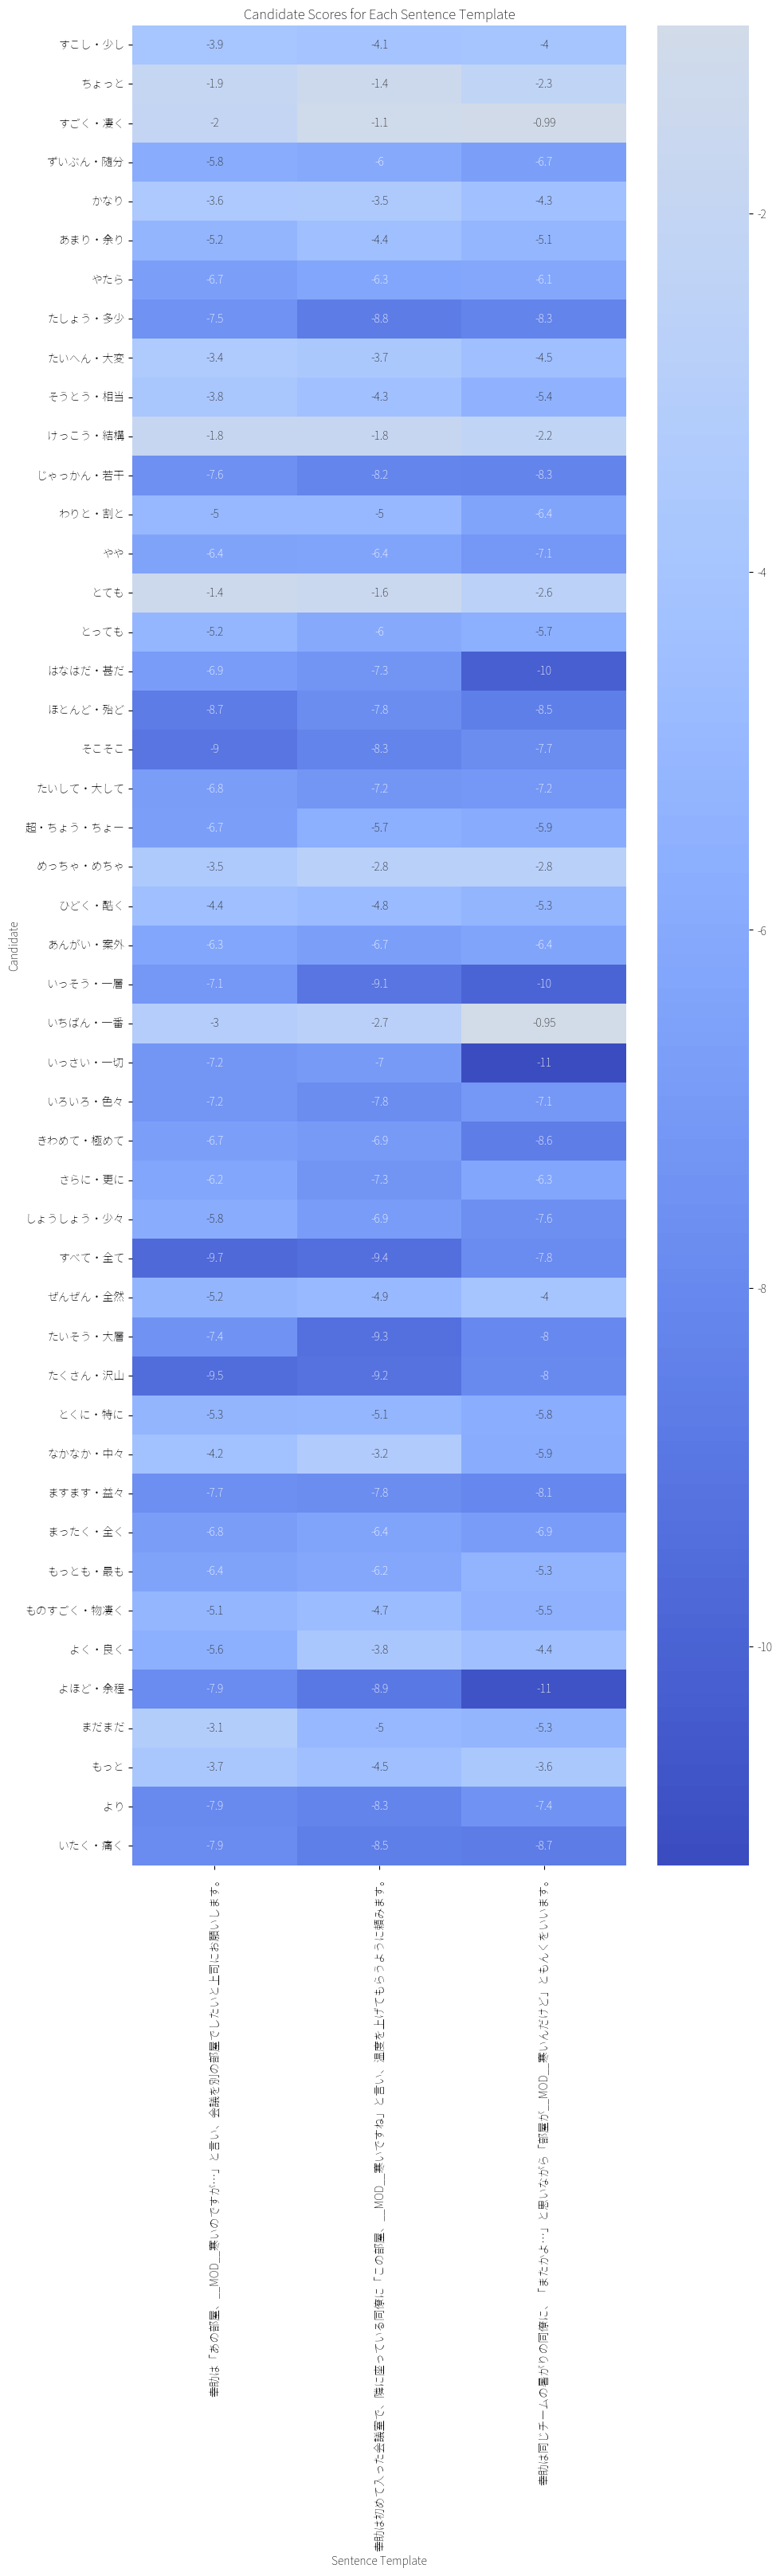

In [35]:
# visualize numbers as colors

import matplotlib.pyplot as plt
import seaborn as sns
# plot in hiragana font
plt.rcParams['font.family'] = 'Noto Sans CJK JP'  # or whatever you confirmed is installed
plt.figure(figsize=(10, 30))
sns.heatmap(df, annot=True, cmap="coolwarm", center=0)
plt.title("Candidate Scores for Each Sentence Template")
plt.xlabel("Sentence Template")
plt.ylabel("Candidate")
plt.show()

# df.to_csv("/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/Aug11perturb_context_results.csv")

In [41]:
en_sentence_templates = [
    "Terry says to his boss, \"That room is __MOD__ cold...\" and asks to hold the meeting in a different room.",
    "Terry, in a conference room he's entering for the first time, says to the colleague sitting next to him, \"This room is __MOD__ cold, isn't it,\" and asks them to turn up the temperature.",
    "Terry, thinking \"not this again...\", complains to a teammate on his team who tends to run hot, \"The room is __MOD__ cold,\"",
]



results = {}  # {sentence_template: {candidate: score}}
for sentence_template in en_sentence_templates:
    print("Sentence template:", sentence_template)
    results[sentence_template] = get_candidate_scores(sentence_template, EN_MODIFIERS)
    print("Scores:", results[sentence_template])
    break

df = pd.DataFrame(results)          # columns = sentence templates, index = candidates
df.index.name = "candidate"
# visualize numbers as colors

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df, annot=True, cmap="coolwarm", center=0)
plt.title("Candidate Scores for Each Sentence Template")
plt.xlabel("Sentence Template")
plt.ylabel("Candidate")
plt.show()

# df.to_csv("/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/Aug11perturb_context_results.csv")



Sentence template: Terry says to his boss, "That room is __MOD__ cold..." and asks to hold the meeting in a different room.


Loading weights: 100%|██████████| 202/202 [00:00<00:00, 5356.07it/s]
[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 202/202 [00:00<00:00, 16517.84it/s]
[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when 

KeyboardInterrupt: 

visualize and save plots

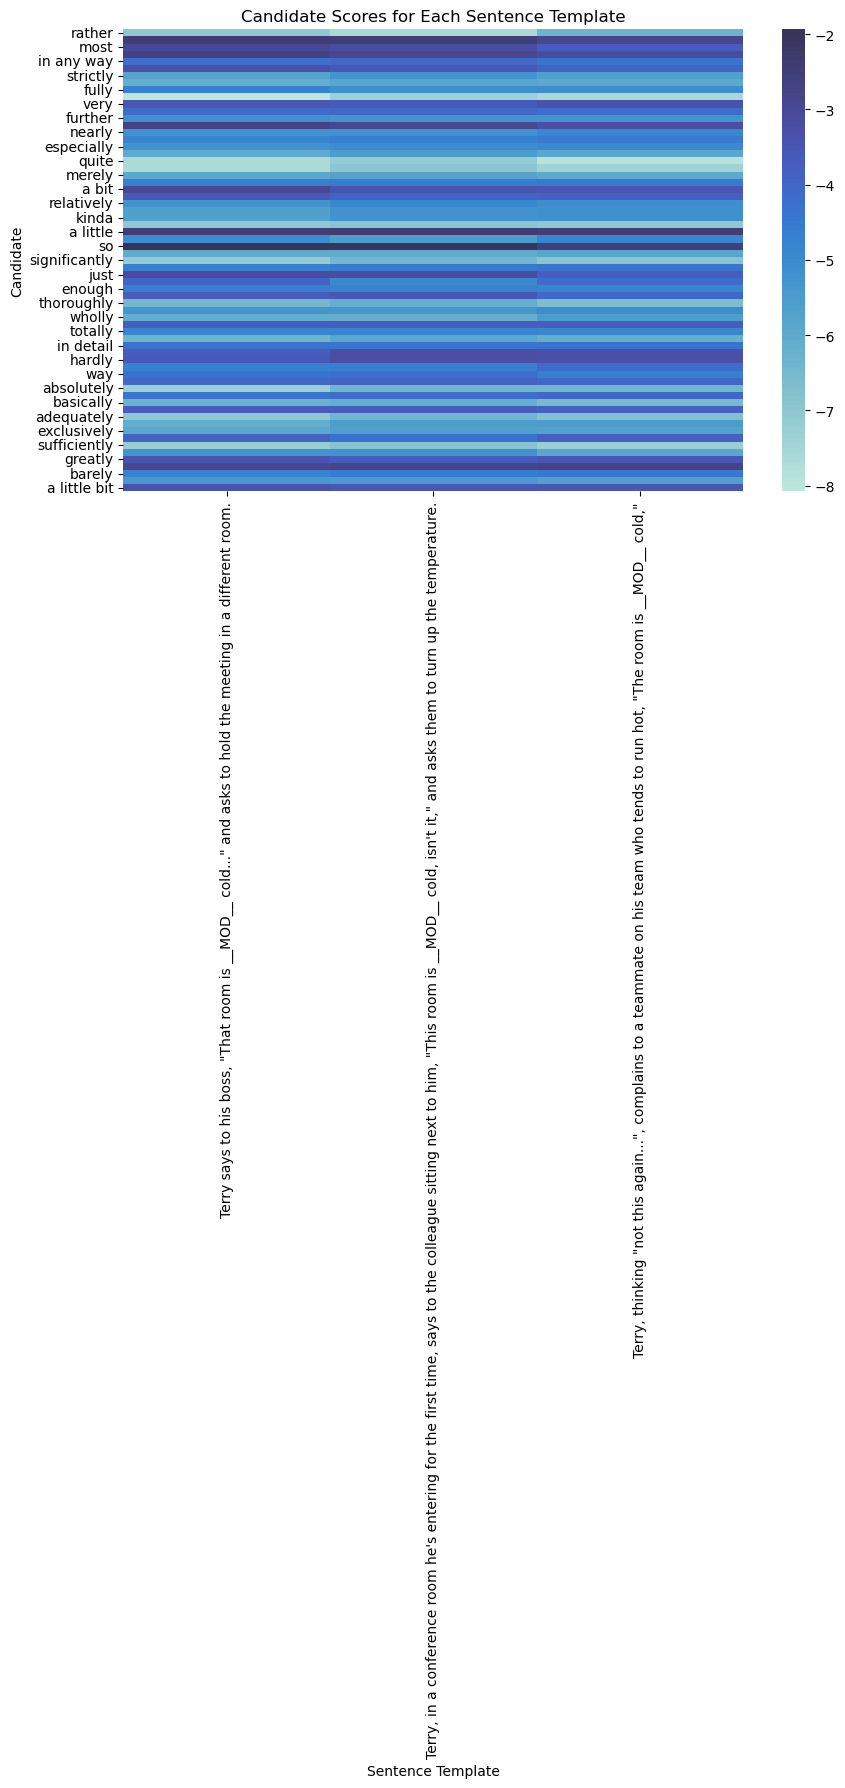

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df, center=0)
plt.title("Candidate Scores for Each Sentence Template")
plt.xlabel("Sentence Template")
plt.ylabel("Candidate")
plt.show()
df.to_csv("/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/enAug11perturb_context_results.csv")
